# Spatial perturbation benchmark — the phase-1 pipeline

Evaluates how well a model predicts the **spatial effect of a CRISPR perturbation**: when a gene is knocked out, how does the perturbed cell itself change, and how does that change spread to its spatial neighbours? The same cell is never measured both perturbed and unperturbed, so everything is scored at the **distribution level** against a **control reference**. Run on the lab server (env `spatial-tumor-ai`), where the Saunders `.h5mu` slices and the offline scGEN dumps live.

## 0. What's new in this refactor (read this first)

**1. Two-layer adapters.** An *input* adapter (`SaundersAdapter`) normalises a raw `.h5mu` slice into one `StandardData`. An *output* adapter (`adapters.internal_output.to_prediction`, `models.scgen_model.ScgenSeedModel`) normalises every model's native output. Models never touch each other's formats.

**2. The 3-dim output contract `{D1, D2, D3}`** (`spbench.prediction.StandardPrediction`). Every prediction is expressed as up to three dims, and a model fills only the ones it covers (`.covered_dims()` / `.as_dict()`):
- **D1 — self**: the perturbed cell's OWN expression shift (the seed).
- **D2 — niche expression**: the aggregated bystander-neighbour expression shift.
- **D3 — niche composition**: the neighbourhood cell-type composition (a simplex).
This is the **capability matrix**: scGEN is a D1-only model; the Gaussian/GCN propagation baselines cover D2; D3 comes from the niche module. A model is only ever scored on the dims it actually covers.

**3. Sample-level aggregate control** (`reference_aggregate.aggregate_control` -> `harness._control_reference_aggregate`). The reference 'unperturbed' state is now a per-cell-type aggregate over CONTROL cells only — no nearest-neighbour matched-control pairing in feature space, so no matched-control leakage. The SAME aggregate-control reference now drives EVERY comparison: the D1 seed baseline (`seed_ref`) and the D2 niche no-effect baseline (`e_null` = the average same-type control cell's neighbourhood) both come from `reference_aggregate.control_reference_centers` — the old `match_reference_centers` expression-nearest-neighbour matching is fully retired. `run_benchmark` uses this by default.

**4. `eval_X` — one unified scoring space.** PCC-delta is not cross-space robust, so the prediction, the observed cells, and the delta baseline must all be compared in the SAME space. For scGEN the natural space is its log-norm training space: we pass `eval_X=lognorm_X` (the `build_lognorm_X` matrix) into `fill_2x2`, which slices the observed/reference seed cells into that same matrix so scGEN's D1 is scored fairly.

**5. MC-spatial quadrant x dimension stratification.** MC-spatial flags, per guide, whether a real **Self** (X) and/or **Niche** (Y) effect exists, giving four quadrants: **Both**, **X-Only (Self)**, **Y-Only (Niche)**, **Inert**. We score **D1 only where there is Self signal** (X-Only/Both), **D2 only where there is Niche signal** (Y-Only/Both), and use the **Inert** quadrant as a rigorous **negative control** (a good model should predict ~no effect there). This avoids diluting a niche score over perturbations that have no niche signal.

## 1. Config
All server-specific paths live here, at the top, so a server run only edits this one cell. `SLICE_DIR` is the Saunders directory; `MAX_FILES` how many slices to pool. The two OPTIONAL inputs — `SCGEN_DUMP_DIR` (offline `{P}_seed.h5ad` dumps) and `DUAL_METRICS_CSV` (MC-spatial `*_Dual_Metrics.csv`) — may be left as `None`/missing; the notebook then runs baseline-only / unstratified and says so explicitly.

In [1]:
from pathlib import Path
# --- this run: Batch_10_Slice_0, scGEN dumps for 4 significant guides (paths under runs/) ---
SLICE_DIR = '/home/chengzheng/sp-perturb-benchmark/runs/scgen/scgen_slice'
MAX_FILES = 1
COUNTS_LAYER = 'X'
SCGEN_DUMP_DIR = '/home/chengzheng/sp-perturb-benchmark/runs/scgen/scgen_out'
DUAL_METRICS_CSV = None
EVAL = ['Rrn3', 'Sec61b', 'Hspa5', 'Vcp']
K_GRAPH, K_REF, NICHE_HOPS = 15, 5, 1
print('SLICE_DIR        =', SLICE_DIR)
print('SCGEN_DUMP_DIR   =', SCGEN_DUMP_DIR)
print('DUAL_METRICS_CSV =', DUAL_METRICS_CSV)
print('EVAL =', EVAL)


SLICE_DIR        = /home/chengzheng/sp-perturb-benchmark/runs/scgen/scgen_slice
SCGEN_DUMP_DIR   = /home/chengzheng/sp-perturb-benchmark/runs/scgen/scgen_out
DUAL_METRICS_CSV = None
EVAL = ['Rrn3', 'Sec61b', 'Hspa5', 'Vcp']


## 1b. Imports

In [2]:
import matplotlib
%matplotlib inline
import numpy as np, pandas as pd

from spbench.adapters.saunders import SaundersAdapter
from spbench.adapters.scgen_export import build_lognorm_X
from spbench.adapters.internal_output import to_prediction
from spbench.prediction import StandardPrediction
from spbench.graph import build_knn_graph
from spbench.niche import build_spatial_graph, compute_niche_composition
from spbench.reference_aggregate import aggregate_control
from spbench.config import run_benchmark
from spbench.harness import (fill_2x2, _control_reference_aggregate, _control_residuals)
from spbench.compare import evaluate_seed
from spbench.models.trivial_seed import TrivialSeed
from spbench.models.gaussian_prop import GaussianProp
from spbench.models.gcn_prop import SimpleGCN
from spbench import mc_spatial_join as mcj
from spbench import mc_spatial_report as mcr

/tmp/ipykernel_290122/3812405710.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import numpy as np, pandas as pd


## 2. Load the data
`SaundersAdapter(SLICE_DIR, max_files=MAX_FILES, counts_layer='X').load()` reads the raw `.h5mu` slice(s) and normalises them into one `StandardData`: `data.X` is the (z-scored) `layers/raw_scaled` matrix; `counts_layer='X'` ALSO loads the raw integer counts into `data.meta['counts']` (needed for scGEN's log-norm space in §6).

In [3]:
data = SaundersAdapter(SLICE_DIR, max_files=MAX_FILES, counts_layer=COUNTS_LAYER).load()
n_pert = len(data.perturbations())
print(f'{data.n_cells} cells, {data.n_genes} genes, {n_pert} perturbations, '
      f'{int(data.is_control.sum())} control cells, {int(data.is_perturbed.sum())} perturbed cells')

# Keep only EVAL perturbations actually present in this slice (defensive).
present = set(data.perturbations())
EVAL = [p for p in EVAL if p in present]
print('evaluating', len(EVAL), 'perturbations present in this slice:', EVAL)
assert EVAL, 'none of the EVAL perturbations are present in this slice — check SLICE_DIR / EVAL'

67512 cells, 209 genes, 202 perturbations, 417 control cells, 6657 perturbed cells
evaluating 4 perturbations present in this slice: ['Rrn3', 'Sec61b', 'Hspa5', 'Vcp']


## 3. Niche graph + cell-type composition (D3 input)
Two interchangeable spatial graphs, both returning a `(2, n_edges)` `[src, dst]` array built WITHIN each slice (no cross-batch edges, no self-loops):
- `build_knn_graph(data, k)` — pure sklearn kNN (the harness/`run_benchmark` default).
- `build_spatial_graph(data, n_neighs)` — squidpy-backed (optional; needs squidpy installed).

`compute_niche_composition(data, edges, hops)` then gives a `(n_cells, C)` row-simplex of each cell's neighbourhood cell-type composition — the **D3** quantity. We build the kNN graph here and reuse it everywhere below so the niche definition is consistent.

In [4]:
edges = build_knn_graph(data, k=K_GRAPH)
print('kNN graph:', edges.shape[1], 'directed edges')

# Optional squidpy graph (same (2, n_edges) format); falls back to the kNN graph if squidpy
# is not installed in this env.
try:
    sq_edges = build_spatial_graph(data, n_neighs=K_GRAPH)
    print('squidpy spatial graph:', sq_edges.shape[1], 'edges (drop-in alternative to kNN)')
except Exception as e:
    print('squidpy graph unavailable (', type(e).__name__, '), using kNN graph only')

comp = compute_niche_composition(data, edges, hops=NICHE_HOPS)   # (n_cells, C) D3 row-simplex
C = comp.shape[1]
print('niche composition (D3):', comp.shape, '->', C, 'cell types; row sums ~',
      float(np.nanmean(comp.sum(1)[comp.sum(1) > 0])))

kNN graph: 1012680 directed edges
squidpy graph unavailable ( ModuleNotFoundError ), using kNN graph only


niche composition (D3): (67512, 9) -> 9 cell types; row sums ~ 1.0


### How a model's output becomes a `StandardPrediction` (the output adapter)
`to_prediction(seed_out, prop_out, composition)` maps a model's native arrays onto the `{D1, D2, D3}` contract: it mean-aggregates per-row seed/prop outputs to a single gene vector and L1-normalises the composition to a simplex. `.covered_dims()` / `.as_dict()` then report exactly which dims are filled — this is how the capability matrix is enforced per model.

In [5]:
# Illustration on one perturbation's cells (no scoring here — just the contract).
p0 = EVAL[0]
centers0 = np.where(data.perturbation == p0)[0]
seed_out0 = data.X[centers0]                         # stand-in seed rows (m, G)
comp0 = comp[centers0].mean(0)                       # mean neighbourhood composition (C,)

pred_seed_only = to_prediction(seed_out=seed_out0)                  # a D1-only model (e.g. scGEN)
pred_full      = to_prediction(seed_out=seed_out0, prop_out=seed_out0, composition=comp0)
print(p0, 'seed-only model covers :', pred_seed_only.covered_dims())
print(p0, 'full   model covers    :', pred_full.covered_dims())
print('D3 is a simplex, sums to   :', round(float(pred_full.d3.sum()), 6))

Rrn3 seed-only model covers : ('D1',)
Rrn3 full   model covers    : ('D1', 'D2', 'D3')
D3 is a simplex, sums to   : 1.0


## 4. MC-spatial quadrants (optional)
MC-spatial writes a `*_Dual_Metrics.csv` per slice with two axis p-values per guide: `p_val_specificity` (X = a real **Self/D1** effect) and `p_val_global` (Y = a real **Niche/D2** effect). `mc_spatial_join.load_dual_metrics(csv, p_cutoff, p_mode)` reads it (stdlib `csv`, no pandas) and tags each perturbation with its quadrant — `BOTH`, `X_ONLY`, `Y_ONLY`, `INERT` (label constants live in `mc_spatial_join`). If `DUAL_METRICS_CSV` is unset or missing, we fall back to the unstratified EVAL list and clearly note that MC-spatial was not provided.

In [6]:
QUADRANT_OF = {}        # perturbation -> quadrant label (empty => no MC-spatial labels)
HAVE_MC = bool(DUAL_METRICS_CSV) and Path(DUAL_METRICS_CSV).exists()
if HAVE_MC:
    dual = mcj.load_dual_metrics(DUAL_METRICS_CSV, p_cutoff=0.05, p_mode='raw')
    QUADRANT_OF = {d['perturbation']: d['quadrant'] for d in dual}
    from collections import Counter
    counts = Counter(QUADRANT_OF.get(p, mcj.UNKNOWN) for p in EVAL)
    print('MC-spatial quadrants for the EVAL guides:')
    for q in (mcj.BOTH, mcj.X_ONLY, mcj.Y_ONLY, mcj.INERT, mcj.UNKNOWN):
        if counts.get(q):
            print(f'  {q:18s}: {counts[q]}')
    print('  (Inert is the negative control; D1 is scored on Self/Both, D2 on Niche/Both.)')
else:
    print('NOTE: MC-spatial Dual_Metrics.csv not provided (DUAL_METRICS_CSV is unset/missing).')
    print('      -> running UNSTRATIFIED on the EVAL list; the §7 stratified report is skipped.')

NOTE: MC-spatial Dual_Metrics.csv not provided (DUAL_METRICS_CSV is unset/missing).
      -> running UNSTRATIFIED on the EVAL list; the §7 stratified report is skipped.


## 5. Run the baselines (D1 seed + D2 niche)
`run_benchmark` now uses the **sample-level aggregate control** by default (`_control_reference_aggregate`) — no matched-control feature pairing. For each perturbation it composes a **TrivialSeed** (D1 floor), a **Gaussian-kernel** baseline propagation and a self-supervised **GCN** learned propagation (both D2), and scores them.

**We report everything as `log(E-distance)`: LOWER = better, with NO subtraction.** From `res['seed'][p]['e_samples']` and `res['compare'][p]['e']` we take the log of the (mean) energy distance to the observed perturbed cells:
- **D1** (`d1_logE`) — the seed/TrivialSeed log E; `d1_null_logE` is the **control-seed reference** (the same-type aggregate-control seed).
- **D2** (`d2_logE`) — the deployable `model+learned` niche log E; `d2_null_logE` is the **no-effect reference** (the aggregate same-type control niche — the neighbourhood of the average unperturbed cell of that type), and `d2_oracle_logE` is the **leakage-free ceiling**.

`null` and `oracle` are **reference values shown alongside, never subtracted** — a method beats no-effect when its `*_logE` sits **below** `*_null_logE`. PCC-delta (`d1_pcc`/`d2_pcc`) is kept only as a *supplementary* column.

In [7]:
res = run_benchmark(data, perturbations=EVAL, k=K_GRAPH, k_ref=K_REF,
                    gcn_kwargs={'hidden': 64, 'epochs': 30})

# Everything below is reported as log(E-distance): LOWER = better, NO subtraction.
# null (no-effect aggregate-control niche) and oracle (leakage-free ceiling) are
# REFERENCE values shown alongside, never subtracted. PCC-delta is supplementary.
def _seed_logE(e_list):
    """log of the mean per-repeat seed E (guard mean>0, else nan)."""
    m = float(np.nanmean(e_list)) if len(e_list) else float('nan')
    return np.log(m) if m > 0 else float('nan')

rows = []
for p in EVAL:
    s = res['seed'][p]; c = res['compare'][p]
    es = s.get('e_samples', {})
    rows.append(dict(
        perturbation=p,
        quadrant=QUADRANT_OF.get(p, mcj.UNKNOWN),
        d1_logE=_seed_logE(es.get('model', [])),            # D1 seed (TrivialSeed) log E
        d1_null_logE=_seed_logE(es.get('null', [])),        # D1 control-seed reference
        d2_logE=np.log(c['e']['model+learned']),            # D2 niche (deployable) log E
        d2_null_logE=np.log(c['e']['null']),                # D2 no-effect reference
        d2_oracle_logE=(np.log(c['e']['oracle']) if 'oracle' in c['e'] else float('nan')),  # D2 ceiling ref
        d1_pcc=s['pcc_delta'], d2_pcc=c['pcc']['model+learned'],  # supplementary (PCC-delta)
        leak_ok=res['leakage_pass'][p],
    ))
# Sort by D2 log E ascending (lower = better); null/oracle columns are references, not scores.
base_df = pd.DataFrame(rows).sort_values('d2_logE', ascending=True).reset_index(drop=True)
base_df

/home/chengzheng/.conda/envs/concert/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


benchmark:   0%|          | 0/4 [00:00<?, ?it/s]

benchmark:  25%|██▌       | 1/4 [00:03<00:10,  3.51s/it]

benchmark:  50%|█████     | 2/4 [00:06<00:06,  3.38s/it]

benchmark:  75%|███████▌  | 3/4 [00:10<00:03,  3.30s/it]

benchmark: 100%|██████████| 4/4 [00:13<00:00,  3.22s/it]

benchmark: 100%|██████████| 4/4 [00:13<00:00,  3.28s/it]

,perturbation,quadrant,d1_logE,d1_null_logE,d2_logE,d2_null_logE,d2_oracle_logE,d1_pcc,d2_pcc,leak_ok
0,Vcp,Unknown,1.690002,-0.357871,-1.469264,-2.031924,-1.700345,0.345440,0.142591,True
1,Hspa5,Unknown,1.671904,-0.626126,-1.354047,-1.909586,-1.676984,0.388707,0.014761,True
2,Rrn3,Unknown,1.696740,-0.932146,-1.352306,-2.001636,-1.557829,0.236478,0.013082,True
3,Sec61b,Unknown,1.718162,-0.728037,-1.260347,-1.881237,-1.518714,0.392771,0.105252,True


## 5b. Seed / niche method-comparison box plots (the headline view)
Mirrors the CONCERT-style figure but as **three boards**: **one box per method**, box = that method's pooled **per-repeat matched-n energy distance** (`res[...]['e_samples']`), shown as **log(E-distance), lower = better**.
- **seed** — all models together; dashed `null (floor)` = same-type control center. **No upper bound** (GT seed = the observed center itself -> energy ~0, trivial).
- **niche . seed-only + Gaussian** — box = model seed propagated by the shared Gaussian baseline; upper bound = **GT seed + Gaussian** (cell-1, the baseline-prop ceiling, isolates seed quality).
- **niche . end-to-end (GCN mock)** — box = the learned-prop niche; upper bound = **GT seed + GCN** (cell-2). GCN stands in as a mock end-to-end model until a real one (CONCERT) is wired in.
Upper bounds are **per-prop** (each prop has its own GT-seed ceiling). This is `plot_seed_prop(res)`.

seed board   : ['seed model'] (floor only, no upper bound)
niche tier-1 : ['Gaussian (seed-only)'] | refs ['null (floor)', 'GT-seed (upper)'] (Gaussian, upper = GT+Gaussian)
niche tier-2 : ['GCN (end-to-end mock)'] | refs ['null (floor)', 'GT-seed (upper)'] (GCN mock, upper = GT+GCN)


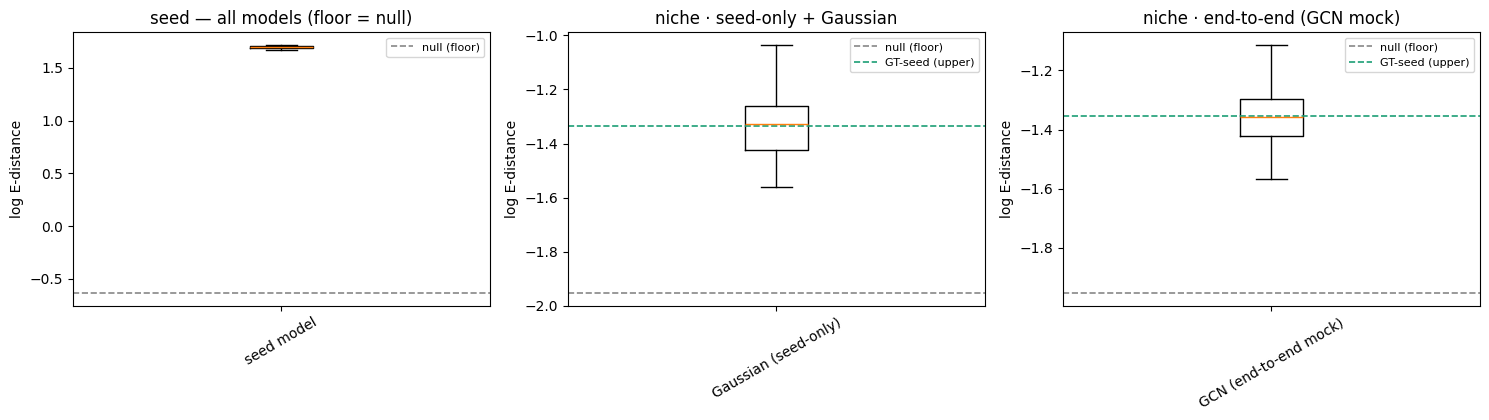

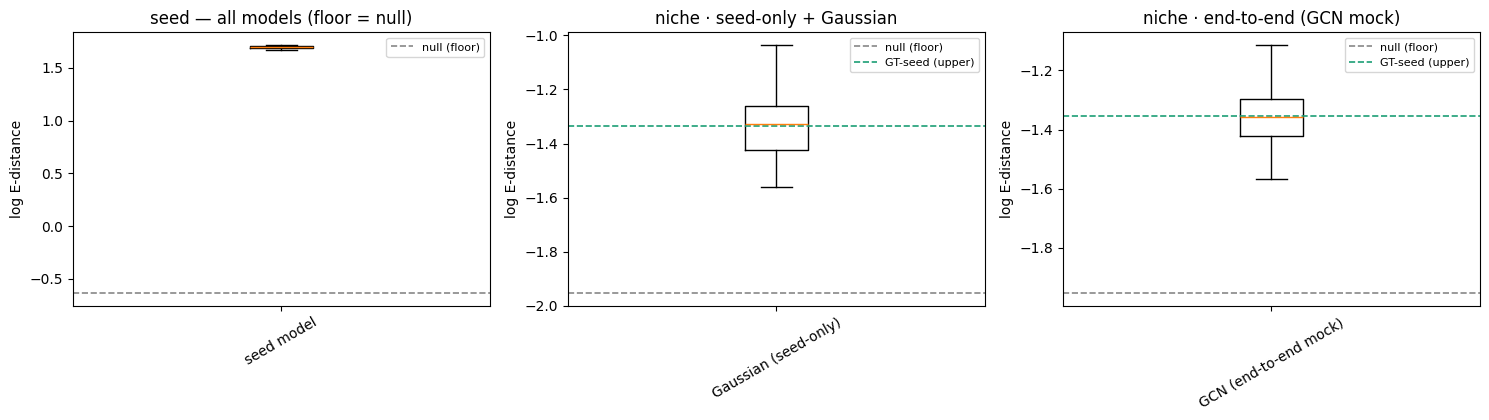

In [8]:
from spbench.plotting import plot_seed_prop, collect_seed_samples, collect_niche_tier
fig = plot_seed_prop(res)
fig.savefig('seed_prop_methods.png', dpi=130, bbox_inches='tight')
_sb, _ = collect_seed_samples(res)
_b1, _d1 = collect_niche_tier(res, 'base'); _b2, _d2 = collect_niche_tier(res, 'learned')
print('seed board   :', list(_sb), '(floor only, no upper bound)')
print('niche tier-1 :', list(_b1), '| refs', list(_d1), '(Gaussian, upper = GT+Gaussian)')
print('niche tier-2 :', list(_b2), '| refs', list(_d2), '(GCN mock, upper = GT+GCN)')
fig

## 6. scGEN — a D1-only conditional model (optional)
scGEN is run OFFLINE in its own env; per perturbation it dumps `{P}_seed.h5ad` (a per-center-aligned predicted-seed array). `ScgenSeedModel({P: path})` loads it and serves it as the model seed; `.centers(P)` gives the StandardData center indices the rows align to. We score scGEN's **D1** in its own log-norm space: build `lognorm_X = build_lognorm_X(data)` (raw counts -> normalize_total 1e4 + log1p) and pass `eval_X=lognorm_X` into `fill_2x2`. `fill_2x2` then slices the observed/reference seed cells into that same matrix (the three are co-spaced) and carries `eval_X=None` downstream, so `evaluate_seed(niches)` scores fairly.

If `SCGEN_DUMP_DIR` has no `{P}_seed.h5ad` for any EVAL perturbation, this cell is a clearly marked no-op and the notebook stays baseline-only.

In [9]:
from spbench.models.scgen_model import ScgenSeedModel

scgen_paths = {}
if SCGEN_DUMP_DIR:
    for p in EVAL:
        f = Path(SCGEN_DUMP_DIR) / f'{p}_seed.h5ad'
        if f.exists():
            scgen_paths[p] = str(f)

scgen_d1 = {}        # perturbation -> {'pcc_delta','mse','n'} for scGEN's D1
if scgen_paths:
    print(f'scGEN dumps found for {len(scgen_paths)}/{len(EVAL)} perturbations.')
    # scGEN's seed_pred lives in the log-norm space -> score there via eval_X=lognorm_X.
    lognorm_X = build_lognorm_X(data)                  # (n_cells, n_genes) log-norm matrix
    X_ref_agg = _control_reference_aggregate(data, edges)   # aggregate-control reference (G1)
    resid = _control_residuals(data)
    base_prop = GaussianProp().fit(data, edges)
    learned_prop = SimpleGCN(hidden=64, epochs=30).fit(data, edges)
    for p, path in scgen_paths.items():
        seed_model = ScgenSeedModel({p: path})         # offline loader; predict_seed is 2-arg
        grid = fill_2x2(data, p, edges, seed_model, base_prop, learned_prop, k_ref=K_REF,
                        X_ref=X_ref_agg, return_niches=True, residuals=resid,
                        eval_X=lognorm_X)              # log-norm scoring space for D1
        niches = grid['_niches']                        # eval_X already consumed into the matrix
        scgen_d1[p] = evaluate_seed(niches, eval_X=niches.get('eval_X'))   # carried eval_X is None here
    # scGEN D1 as log(E-distance) (lower = better); pcc kept supplementary.
    sc_df = pd.DataFrame([dict(perturbation=p, quadrant=QUADRANT_OF.get(p, mcj.UNKNOWN),
                               scgen_d1_logE=_seed_logE(v.get('e_samples', {}).get('model', [])),
                               scgen_d1_pcc=v['pcc_delta'])
                          for p, v in scgen_d1.items()])
    base_df = base_df.merge(sc_df.drop(columns='quadrant'), on='perturbation', how='left')
    display(sc_df.sort_values('scgen_d1_logE', ascending=True).reset_index(drop=True))
else:
    print('NOTE: no scGEN {P}_seed.h5ad dumps found (SCGEN_DUMP_DIR unset/empty).')
    print('      -> running BASELINE-ONLY; scGEN D1 columns are omitted.')

scGEN dumps found for 4/4 perturbations.


,perturbation,quadrant,scgen_d1_logE,scgen_d1_pcc
0,Rrn3,Unknown,2.563928,0.248974
1,Sec61b,Unknown,2.565391,0.279304
2,Vcp,Unknown,2.677686,0.258139
3,Hspa5,Unknown,2.755661,0.258388


### Combined per-perturbation results table
One row per perturbation, all in **log(E-distance), lower = better**: the baselines' **D1** (`d1_logE`, with `d1_null_logE` reference) and **D2** (`d2_logE`, with `d2_null_logE` and `d2_oracle_logE` references), plus scGEN's D1 (`scgen_d1_logE`) when its dumps were found. PCC-delta columns (`d1_pcc`/`d2_pcc`/`scgen_d1_pcc`) are supplementary. This is the per-perturbation evidence behind the capability matrix in §7.

In [10]:
base_df

,perturbation,quadrant,d1_logE,d1_null_logE,d2_logE,d2_null_logE,d2_oracle_logE,d1_pcc,d2_pcc,leak_ok,scgen_d1_logE,scgen_d1_pcc
0,Vcp,Unknown,1.690002,-0.357871,-1.469264,-2.031924,-1.700345,0.345440,0.142591,True,2.677686,0.258139
1,Hspa5,Unknown,1.671904,-0.626126,-1.354047,-1.909586,-1.676984,0.388707,0.014761,True,2.755661,0.258388
2,Rrn3,Unknown,1.696740,-0.932146,-1.352306,-2.001636,-1.557829,0.236478,0.013082,True,2.563928,0.248974
3,Sec61b,Unknown,1.718162,-0.728037,-1.260347,-1.881237,-1.518714,0.392771,0.105252,True,2.565391,0.279304


## 7. Capability matrix + stratified report
The **capability matrix** below reports each model x dimension as **mean log(E-distance) (LOWER = better)**, with `null`/`oracle` as **reference rows** (never subtracted). A model is only scored on the dims it covers (NaN otherwise).

The optional **stratified report** then joins the MC-spatial quadrant onto each model and reports, **per dimension, only over the quadrants where that dimension has signal**, with **Inert as the negative control**:
- **D1** (self) — scored on **X-Only + Both** (`mc_spatial_report.DIMENSION_QUADRANTS['d1']`).
- **D2** (niche) — scored on **Y-Only + Both** (`DIMENSION_QUADRANTS['d2']`).
- **Inert** — negative control: a good model has `mean_gain ~ 0` there.

`mc_spatial_report.stratified_report(records, dim_gain_fields)` consumes records that carry a `quadrant` label (from `join_quadrants`) plus per-dimension gain fields. Here those gain fields are an **internal** quantity derived from the log-E columns — how far each method sits **below** its no-effect `null` log E (positive = better) — used only to drive the quadrant stratification and the Inert negative-control read; the headline tables above remain log(E-distance). If MC-spatial was not provided, we show the unstratified capability matrix above only.

In [11]:
def _capability_matrix(df):
    """Mean log(E-distance) per model x dimension (LOWER = better); null/oracle are
    reference rows, not models. NaN = dimension not covered by that model."""
    cm = {'TrivialSeed (seed)': {'D1': float(np.nanmean(df['d1_logE'])), 'D2': np.nan, 'D3': np.nan},
          'Gaussian/GCN (niche)': {'D1': np.nan,
                                   'D2': float(np.nanmean(df['d2_logE'])), 'D3': np.nan},
          'null (reference)': {'D1': float(np.nanmean(df['d1_null_logE'])),
                               'D2': float(np.nanmean(df['d2_null_logE'])), 'D3': np.nan},
          'oracle (reference)': {'D1': np.nan,
                                 'D2': float(np.nanmean(df['d2_oracle_logE'])), 'D3': np.nan},
          'niche-composition module': {'D1': np.nan, 'D2': np.nan, 'D3': 'simplex (built in §3)'}}
    if 'scgen_d1_logE' in df.columns:
        cm['scGEN (seed)'] = {'D1': float(np.nanmean(df['scgen_d1_logE'])), 'D2': np.nan, 'D3': np.nan}
    return pd.DataFrame(cm).T

print('Capability matrix — mean log(E-distance), LOWER = better; null/oracle = reference rows:')
display(_capability_matrix(base_df))

Capability matrix — mean log(E-distance), LOWER = better; null/oracle = reference rows:


,D1,D2,D3
TrivialSeed (seed),1.694202,NaN,NaN
Gaussian/GCN (niche),NaN,-1.358991,NaN
null (reference),-0.661045,-1.956096,NaN
oracle (reference),NaN,-1.613468,NaN
niche-composition module,NaN,NaN,simplex (built in §3)
scGEN (seed),2.640667,NaN,NaN


In [12]:
if HAVE_MC:
    # The headline tables above are log(E-distance); this stratified report still uses an
    # INTERNAL gain (how far a method sits BELOW its no-effect null log E, so positive = better)
    # purely to drive the MC-spatial quadrant stratification / negative-control read.
    records = []
    for _, r in base_df.iterrows():
        # D1 gain = how far the seed log E sits below the control-seed reference (null) log E.
        d1_ref = r['d1_null_logE']
        d1_self = r['scgen_d1_logE'] if ('scgen_d1_logE' in base_df.columns
                                         and pd.notna(r.get('scgen_d1_logE'))) else r['d1_logE']
        d1_gain = float(d1_ref - d1_self)
        # D2 gain = how far the niche log E sits below the no-effect null log E.
        d2_gain = float(r['d2_null_logE'] - r['d2_logE'])
        records.append({'perturbation': r['perturbation'],
                        'gain_d1': d1_gain, 'gain_d2': d2_gain})
    # Attach quadrants from the CSV (left join; absent guides -> 'Unknown').
    records = mcj.join_quadrants(records, DUAL_METRICS_CSV, key='perturbation', p_mode='raw')
    report = mcr.stratified_report(records, dim_gain_fields={'d1': 'gain_d1', 'd2': 'gain_d2'})
    rep_df = pd.DataFrame(report)
    print('Stratified report (D1 on Self/Both, D2 on Niche/Both, Inert = negative control):')
    display(rep_df)
    print('Read: mean_gain should be > 0 in the signal rows and ~ 0 in the is_negative_control'
          ' (Inert) rows.')
else:
    print('MC-spatial not provided -> stratified report skipped. Unstratified capability'
          ' matrix above is the summary; rerun with DUAL_METRICS_CSV set for the quadrant'
          ' x dimension breakdown with the Inert negative control.')

MC-spatial not provided -> stratified report skipped. Unstratified capability matrix above is the summary; rerun with DUAL_METRICS_CSV set for the quadrant x dimension breakdown with the Inert negative control.


## 8. Bottom line — how to read it
Everything is **log(E-distance): LOWER = better**, with `null`/`oracle` shown as references (never subtracted).
- **Capability matrix.** Each model is scored only on the dims it covers: scGEN on **D1**, the Gaussian/GCN propagation on **D2**, the niche module supplies **D3**. NaN means 'dim not covered', not 'failed'. `null` and `oracle` are reference rows.
- **scGEN vs TrivialSeed on D1.** scGEN is a conditional model; its D1 log E should sit **below TrivialSeed's** (lower = closer to the observed seed) and **near the `null` reference on Inert** in the stratified read. A D1 far below null on Inert would mean scGEN is hallucinating an effect where MC-spatial found none.
- **D2 niche.** `model+learned` log E **below `d2_null_logE`** beats predicting 'the neighbours did not change', and that advantage should be concentrated in the **Niche/Both** quadrants, not in Inert; `d2_oracle_logE` is the leakage-free floor.
- **eval_X.** scGEN's D1 is scored in its log-norm space; the baselines' D1 is in `data.X` space — compare each model to its own `null` reference, not the raw log-E numbers across spaces.

In [13]:
# All numbers are log(E-distance), LOWER = better; null/oracle are references (never subtracted).
has_scgen = 'scgen_d1_logE' in base_df.columns
print('Per-dimension coverage this run:')
print('  D1 (self)        : TrivialSeed' + (', scGEN' if has_scgen else '')
      + '  (scored on Self/Both quadrants)')
print('  D2 (niche expr)  : Gaussian + GCN (model+learned)  (scored on Niche/Both quadrants)')
print('  D3 (niche comp)  : compute_niche_composition simplex, shape', comp.shape)
d2_mean = float(np.nanmean(base_df['d2_logE'])); d2_null = float(np.nanmean(base_df['d2_null_logE']))
n_d2_win = int((base_df['d2_logE'] < base_df['d2_null_logE']).sum())
print(f'\nD2: mean log E {d2_mean:.3f}  vs  null {d2_null:.3f}  (lower = better)')
print(f'    {n_d2_win}/{len(base_df)} guides beat no-effect (D2 log E below null).')
if has_scgen:
    sc_mean = float(np.nanmean(base_df['scgen_d1_logE'])); tr_mean = float(np.nanmean(base_df['d1_logE']))
    better = base_df['scgen_d1_logE'] < base_df['d1_logE']
    print(f'D1: scGEN mean log E {sc_mean:.3f}  vs  TrivialSeed {tr_mean:.3f}  (lower = better);'
          f' scGEN lower on {int(better.sum())}/{int(better.notna().sum())} guides.')
if not HAVE_MC:
    print('\n(MC-spatial labels not provided -> the Inert negative control was not evaluated.)')

Per-dimension coverage this run:
  D1 (self)        : TrivialSeed, scGEN  (scored on Self/Both quadrants)
  D2 (niche expr)  : Gaussian + GCN (model+learned)  (scored on Niche/Both quadrants)
  D3 (niche comp)  : compute_niche_composition simplex, shape (67512, 9)

D2: mean log E -1.359  vs  null -1.956  (lower = better)
    0/4 guides beat no-effect (D2 log E below null).
D1: scGEN mean log E 2.641  vs  TrivialSeed 1.694  (lower = better); scGEN lower on 0/4 guides.

(MC-spatial labels not provided -> the Inert negative control was not evaluated.)


## 9. Visual summary (the headline result)
A single **capability-matrix heatmap** over **mean log(E-distance) (LOWER = better)** — each model scored only on the dims it covers ('—' = not covered), with `null`/`oracle` as reference rows. The per-method seed (D1) and niche (D2) log-E box plots are the **§5b** figure (`plot_seed_prop`); this panel is the compact model x dimension summary. The figure is saved next to the notebook as `run_benchmark_results.png`, followed by a clean text dump of the final table.

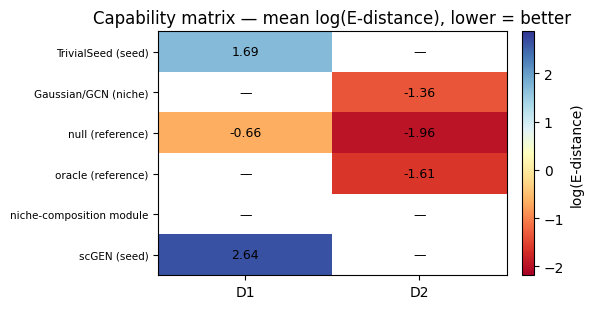

saved figure -> notebooks/run_benchmark_results.png  (see §5b for per-method box plots)


In [14]:
import matplotlib.pyplot as plt

# Single capability-matrix heatmap over mean log(E-distance), LOWER = better.
# (The per-method seed/niche log-E box plots are the §5b plot_seed_prop figure.)
fig, ax = plt.subplots(figsize=(6, 3.2))
cm = _capability_matrix(base_df)
num = cm[['D1', 'D2']].apply(pd.to_numeric, errors='coerce').astype(float)
vals = num.values.astype(float)
finite = vals[np.isfinite(vals)]
if finite.size:
    pad = 0.05 * (float(np.nanmax(finite)) - float(np.nanmin(finite)) + 1e-9)
    vmin, vmax = float(np.nanmin(finite)) - pad, float(np.nanmax(finite)) + pad
else:
    vmin, vmax = None, None
im = ax.imshow(vals, aspect='auto', cmap='RdYlBu', vmin=vmin, vmax=vmax)
ax.set_xticks(range(num.shape[1])); ax.set_xticklabels(num.columns)
ax.set_yticks(range(num.shape[0])); ax.set_yticklabels(num.index, fontsize=7.5)
for i in range(num.shape[0]):
    for j in range(num.shape[1]):
        v = vals[i, j]
        ax.text(j, i, '—' if np.isnan(v) else f'{v:.2f}', ha='center', va='center', fontsize=9)
ax.set_title('Capability matrix — mean log(E-distance), lower = better')
fig.colorbar(im, ax=ax, fraction=.046, pad=.04, label='log(E-distance)')
fig.tight_layout()
fig.savefig('run_benchmark_results.png', dpi=130, bbox_inches='tight')
plt.show()
print('saved figure -> notebooks/run_benchmark_results.png  (see §5b for per-method box plots)')

In [15]:
# ---- clean text dump of the final results (all log(E-distance), lower = better) ----
pd.set_option('display.float_format', lambda v: f'{v:.4f}')
has_scgen = 'scgen_d1_logE' in base_df.columns
cols = ['perturbation', 'quadrant', 'd1_logE']
if has_scgen:
    cols += ['scgen_d1_logE']
cols += ['d2_logE', 'd2_null_logE', 'd2_oracle_logE']
print('=' * 72)
print('FINAL RESULTS  -  Saunders Batch_10_Slice_0  (one row per guide; log E, lower = better)')
print('=' * 72)
print(base_df[cols].to_string(index=False))
print('\nCapability matrix (mean log(E-distance), lower = better; - = dim not covered; '
      'null/oracle = reference rows):')
print(_capability_matrix(base_df).to_string())
if has_scgen:
    sc_mean = float(np.nanmean(base_df['scgen_d1_logE'])); tr_mean = float(np.nanmean(base_df['d1_logE']))
    n_win = int((base_df['scgen_d1_logE'] < base_df['d1_logE']).sum())
    print(f'\nD1: scGEN mean log E {sc_mean:.3f}  vs  TrivialSeed mean log E {tr_mean:.3f}'
          f'   (lower wins; scGEN lower on {n_win}/{len(base_df)} guides)')
n_d2 = int((base_df['d2_logE'] < base_df['d2_null_logE']).sum())
d2_mean = float(np.nanmean(base_df['d2_logE'])); d2_null = float(np.nanmean(base_df['d2_null_logE']))
print(f'D2: mean log E {d2_mean:.3f}  vs  null {d2_null:.3f}  '
      f'(below null on {n_d2}/{len(base_df)} guides)')

FINAL RESULTS  -  Saunders Batch_10_Slice_0  (one row per guide; log E, lower = better)
perturbation quadrant  d1_logE  scgen_d1_logE  d2_logE  d2_null_logE  d2_oracle_logE
         Vcp  Unknown   1.6900         2.6777  -1.4693       -2.0319         -1.7003
       Hspa5  Unknown   1.6719         2.7557  -1.3540       -1.9096         -1.6770
        Rrn3  Unknown   1.6967         2.5639  -1.3523       -2.0016         -1.5578
      Sec61b  Unknown   1.7182         2.5654  -1.2603       -1.8812         -1.5187

Capability matrix (mean log(E-distance), lower = better; - = dim not covered; null/oracle = reference rows):
                              D1      D2                     D3
TrivialSeed (seed)        1.6942     NaN                    NaN
Gaussian/GCN (niche)         NaN -1.3590                    NaN
null (reference)         -0.6610 -1.9561                    NaN
oracle (reference)           NaN -1.6135                    NaN
niche-composition module     NaN     NaN  simplex (built 